<a href="https://colab.research.google.com/github/Lara-mt/MAT-422/blob/main/MAT422_HW1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Singular Value Decomposition

Singular value decomposition factors a matrix into three matrices

In this example, I will compute the SVD of a small matrix and verify that multiplying the three matrices together reconstructs the original.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress = True)

A = np.array([
    [3.0,1.0,1.0],
    [-1.0,3.0,1.0],
    [0.0,2.0,2.0],
    [2.0,0.0,1.0],
])

print("Matrix A:")
print(A)

print("\nShape of A:")
print(A.shape)

Matrix A:
[[ 3.  1.  1.]
 [-1.  3.  1.]
 [ 0.  2.  2.]
 [ 2.  0.  1.]]

Shape of A:
(4, 3)


Computing the SVD

NumPy's np.linalg.svd() function retutrns three objects:

- 'U': left singular vectors
- 's': singular values
- 'Vt': the transpose of the right singular-vector matrix

I use 'full_matrices=False' so the dimensions of the matrices stay compact.

In [20]:
U,s,Vt = np.linalg.svd(A, full_matrices=False)

print("\nU:")
print(U)

print("\nSingular Values:")
print(s)

print("\nVt:")
print(Vt)

Sigma = np.diag(s)

print("Sigma:")
print(Sigma)


U:
[[-0.5376  0.5976  0.4593]
 [-0.5376 -0.5976  0.4593]
 [-0.581  -0.239  -0.6801]
 [-0.2905  0.4781 -0.34  ]]

Singular Values:
[4.4838 3.7417 0.9462]

Vt:
[[-0.3694 -0.7388 -0.5637]
 [ 0.8944 -0.4472  0.    ]
 [ 0.2521  0.5042 -0.826 ]]
Sigma:
[[4.4838 0.     0.    ]
 [0.     3.7417 0.    ]
 [0.     0.     0.9462]]


In [21]:
## Reconstruct A
A_reconstructed = U @ Sigma @ Vt

print("Original A:")
print(A)

print("\nReconstructed A:")
print(A_reconstructed)

## Verify Numerically
reconstruction_error = np.linalg.norm(A - A_reconstructed)
print("\nReconstruction Error:")
print(reconstruction_error)

print("\nDoes the reconstruction match A?")
print(np.allclose(A, A_reconstructed))

Original A:
[[ 3.  1.  1.]
 [-1.  3.  1.]
 [ 0.  2.  2.]
 [ 2.  0.  1.]]

Reconstructed A:
[[ 3.  1.  1.]
 [-1.  3.  1.]
 [-0.  2.  2.]
 [ 2.  0.  1.]]

Reconstruction Error:
1.6501145247828888e-15

Does the reconstruction match A?
True


The reconstructed matrix is extremely close to the original matrix. The reconstruction error is near zero and 'np.allclose()' returns "True".

The small difference is caused by floating-point rounding during numerical calculations.

U.T @ U:
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]

Vt @ Vt.T:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

U orthogonal:
True

Vt orthogonal:
True


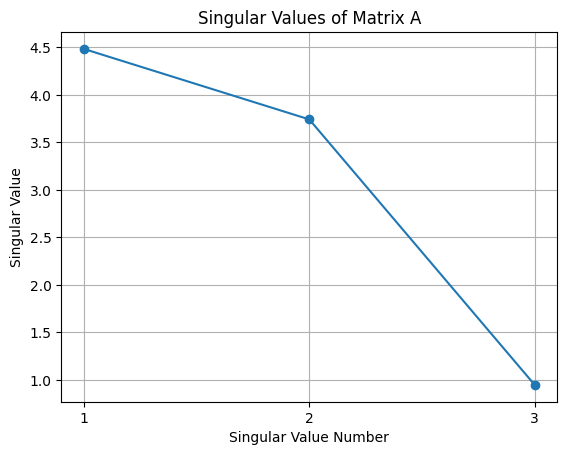

In [22]:
## Checking orthogonality

print("U.T @ U:")
print(U.T @ U)

print("\nVt @ Vt.T:")
print(Vt @ Vt.T)

print("\nU orthogonal:")
print(np.allclose(U.T @ U, np.eye(U.shape[1])))

print("\nVt orthogonal:")
print(np.allclose(Vt @ Vt.T, np.eye(Vt.shape[0])))

##Plot
plt.plot(range(1, len(s) + 1), s, marker='o')

plt.xlabel("Singular Value Number")
plt.ylabel("Singular Value")
plt.title("Singular Values of Matrix A")
plt.xticks(range(1, len(s) + 1))
plt.grid()

plt.show()

Summary of SVD
The singular values show the relative importance of different directions in the matrix. Larger singular values represent directions that contain more of the matrix's structure giving you more information.  

The first singular value is the largest, so the first singular-vector direction contributes the most to representing the matrix. Smaller values tell you less information.

# Low-Rank Matrix Approximation

A Low-rank approximation uses only the largest singular values from SVD.

The goal is to create a simpler version of the original matrix while preserving as much important information as possible.


In [24]:
## Making function for A sub k
def rank_k_approximation(U, s, Vt, k):
  return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]


In [31]:
## Rank 1 Approx
A1 = rank_k_approximation(U, s, Vt, 1)

print("Rank-1 approximation:")
print(A1)

## Rank 2 Approx
A2 = rank_k_approximation(U, s, Vt, 2)

print("\nRank-2 approximation:")
print(A2)

## Reconstruct
A_full = rank_k_approximation(U, s, Vt, len(s))

print("\nFull approximation:")
print(A_full)

## Plot

Rank-1 approximation:
[[0.8904 1.7809 1.359 ]
 [0.8904 1.7809 1.359 ]
 [0.9622 1.9245 1.4685]
 [0.4811 0.9622 0.7343]]

Rank-2 approximation:
[[ 2.8904  0.7809  1.359 ]
 [-1.1096  2.7809  1.359 ]
 [ 0.1622  2.3245  1.4685]
 [ 2.0811  0.1622  0.7343]]

Full approximation:
[[ 3.  1.  1.]
 [-1.  3.  1.]
 [-0.  2.  2.]
 [ 2.  0.  1.]]


The rank 1 approximation keeps only the strongest pattern in a matrix, so it is a rough approximation of the original.

The rank 2 approximation keeps more infomation, so its values are closer to the original matrix.

As the rank increases, the approximation becomes more accurate. If the matrix represented an image, the image would generally look cleaer because more original information was kept.

In [33]:
## Compute Frbenius norm error

error1 = np.linalg.norm(A - A1)
error2 = np.linalg.norm(A - A2)
error_full = np.linalg.norm(A - A_full, ord='fro')

print("Rank-1 error:", error1)
print("Rank-2 error:", error2)
print("Full reconstruction error:", error_full)

Rank-1 error: 3.859444732581453
Rank-2 error: 0.9462101478269649
Full reconstruction error: 1.6501145247828888e-15


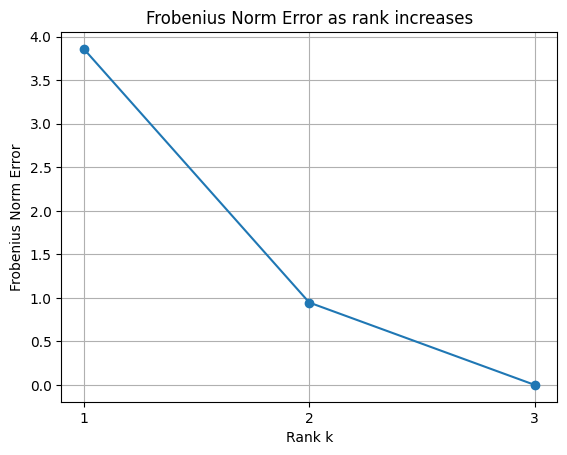

In [37]:
## Increasing k
errors = []
for k in range(1, len(s) + 1):
    A_k = rank_k_approximation(U, s, Vt, k)
    error_k = np.linalg.norm(A - A_k, ord='fro')
    errors.append(error_k)

plt.plot(range(1, len(s) + 1), errors, marker='o')

plt.xlabel("Rank k")
plt.ylabel("Frobenius Norm Error")
plt.title("Frobenius Norm Error as rank increases")
plt.xticks(range(1, len(s) + 1))
plt.grid()
plt.show()

As the rank increases, the approximation error decreases.

When all singular values are used, the reconstructed matrix is nearly identical to the orginal matrix.

# Principal Component Analysis

Principal component analysis is used to find the directions in a dataset that contain the most variation.

The first principal component points in the direction where the data varies the most. The second principal component points in the next most important direction.

PCA can be computed using singular value decomposition after first centering the data.

Original data:
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


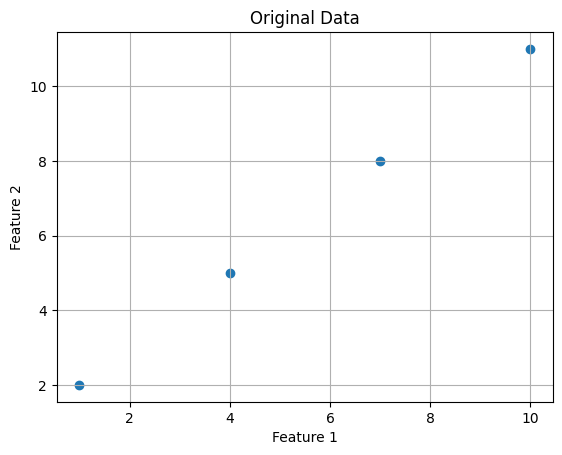

In [38]:
## small data set

X = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12]
])
print("Original data:")
print(X)

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")
plt.grid()
plt.show()

In [39]:
## Centering data
mean = np.mean(X, axis=0)
X_centered = X - mean

print("Mean:")
print(mean)

print("\nCentered data:")
print(X_centered)


Mean:
[5.5 6.5 7.5]

Centered data:
[[-4.5 -4.5 -4.5]
 [-1.5 -1.5 -1.5]
 [ 1.5  1.5  1.5]
 [ 4.5  4.5  4.5]]


In [40]:
## Verify data is centered

print("Mean of centered data:")
print(np.mean(X_centered, axis=0))
#

Mean of centered data:
[0. 0. 0.]


PCA works with data that has been centered about zero

Centering means subtracting the mean of each feature from every observation.

This does not change the shape of the data. It only moves the center.

In [41]:
## Apply SVD
U_pca, s_pca, Vt_pca = np.linalg.svd(X_centered, full_matrices=False)

print("Singular values:")
print(s_pca)

print("\nPrincipal directions:")
print(Vt_pca)



Singular values:
[11.619  0.     0.   ]

Principal directions:
[[ 0.5774  0.5774  0.5774]
 [ 0.     -0.7071  0.7071]
 [ 0.8165 -0.4082 -0.4082]]


In [42]:
## Compute PCA Scores
scores = X_centered @ Vt_pca.T

print("PCA scores:")
print(scores)

PCA scores:
[[-7.7942 -0.     -0.    ]
 [-2.5981 -0.     -0.    ]
 [ 2.5981  0.      0.    ]
 [ 7.7942  0.      0.    ]]


In [44]:
## Variance
explained_variance_ratio = s_pca ** 2 / np.sum(s_pca ** 2)

print("Explained variance ratio:")
print(explained_variance_ratio)

Explained variance ratio:
[1. 0. 0.]


The explained variance ratio tells us how much of the variation in the data set is captured by each principal component.

The first principal component captures most of the variation because the data points mainly follow one diagonal direction.

The second principal component captures much less variation because there is very little spread in the direction perpendicular to the main trend.

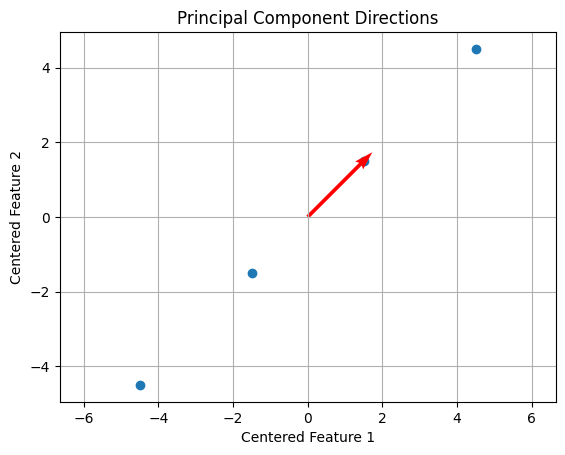

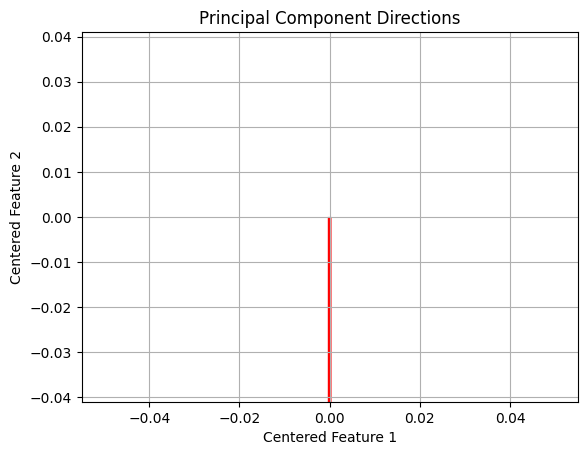

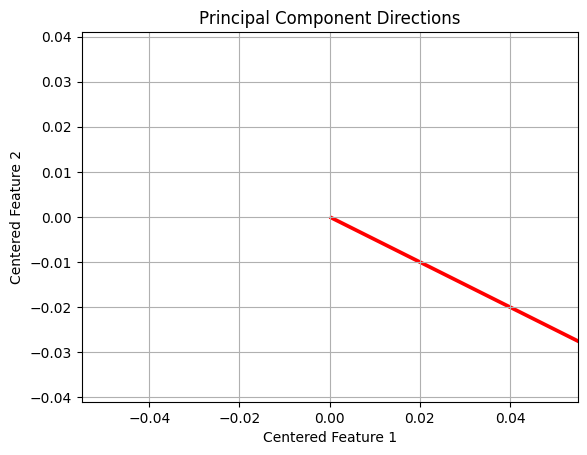

In [45]:
## Plotting centered data and principal directions

plt.scatter(X_centered[:, 0], X_centered[:, 1])

origin = np.array([0,0])

scale = 3

for i in range(len(Vt_pca)):
  direction = Vt_pca[i]

  plt.quiver (
      origin[0],
      origin[1],
      direction[0] * scale,
      direction[1] * scale,
      color='r',
      angles='xy',
      scale_units='xy',
      scale=1,
  )

  plt.xlabel("Centered Feature 1")
  plt.ylabel("Centered Feature 2")
  plt.title("Principal Component Directions")
  plt.grid()
  plt.axis("equal")

  plt.show()

Summary

PCA changed the coordinate system so that the principal components show the main directions of variation in the data.

PC1 points diagonally and follows the main pattern of the data, so it captures almost all of the variation.

The other principal component points downward in this plot and captures very little additional variation.

Because nearly all of the information is captured by PC1, this dataset could be represented using mainly the first principal component with very little information lost.